In [1]:
import numpy as np

In [2]:
class LogisticRegression:
    def __init__(self, lr = 0.01, epochs = 500):
        self.lr = lr
        self.epochs = epochs

        self.w = None
        self.b = None

    def _sigmoid(self,z):
        z = np.clip(z,-500,500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        
        self.w = np.zeros(n)
        self.b = 0.0

        #-----Initialise_Momentum_terms---------#
        v_w = np.zeros(n)
        v_b = 0.0
        beta = 0.9

        for i in range(self.epochs):

            #-------predict--------#
            z = np.dot(X,self.w) + self.b
            y_p = self._sigmoid(z)

            #---gradient_descent---#
            dw = (1 / m) * np.dot(X.T , (y_p - y))
            db = (1 / m) * np.sum(y_p - y)

            #------update----------#
            self.w -= self.lr * dw
            self.b -= self.lr * db
        

    def predict_probab(self,X):
        z = np.dot(X,self.w) + self.b
        return self._sigmoid(z)

    def predict(self,X, ths = 0.5):
        y_pred = self.predict_probab(X)
        return np.array([1.0 if p >= ths else 0.0 for p in y_pred])


In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

In [4]:
X, y = make_classification(
    n_samples=3000,        # Number of rows/data points
    n_features=2,         # Total number of columns/features
    n_informative=2,      # Features that actually help predict the class
    n_redundant=0,        # Linear combinations of informative features (noise columns)
    n_clusters_per_class=1, # How clustered the points are within a class
    class_sep=1.5,        # How far apart the two classes are (higher = easier to split)
    random_state=42       # Reproducible seed
)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [5]:
model = LogisticRegression(epochs=100)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("accuracy : ", accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

accuracy :  0.9766666666666667


array([[295,  10],
       [  4, 291]])

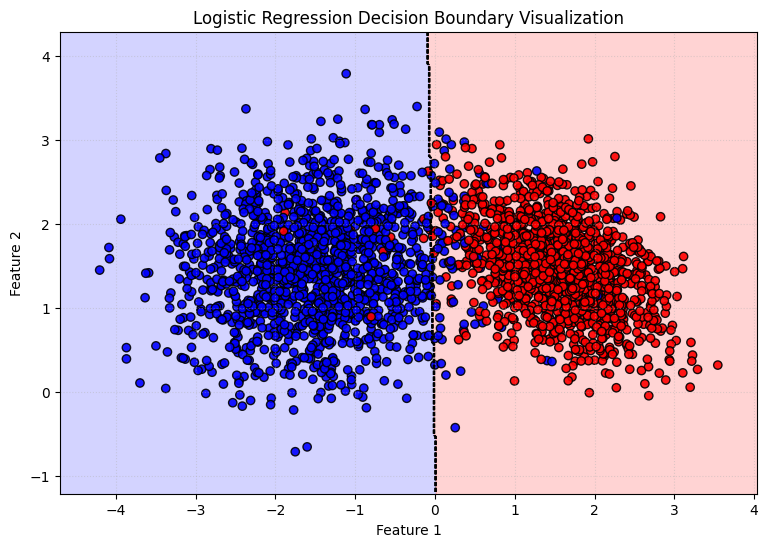

In [6]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# Generate coordinate arrays for the mesh grid (resolution 0.02)
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# 4. Predict the class for every single coordinate on the grid
# .ravel() flattens the grids, np.c_ pairs them up into (x1, x2) rows
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)

# Reshape the flat predictions back into the original grid layout
Z = Z.reshape(xx.shape)

# 5. Plotting
plt.figure(figsize=(9, 6))

# Draw the colored background decision regions
# 'cmap' defines the background colors, 'alpha' controls transparency
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.2)

# Draw the absolute boundary line where the probability shifts (optional but crisp)
plt.contour(xx, yy, Z, colors='black', linewidths=0.8, linestyles='--')

# Superimpose the actual data points on top of the colored regions
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.9)

plt.title('Logistic Regression Decision Boundary Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()